In [1]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [2]:
data_keys = ['23343-5-17',
 '23964-4-22',
 '23656-14-22',
 '21067-10-18',
 '26872-17-20',
 '22846-10-16',
 '27204-5-13']

In [3]:
def knn_consistency(emb0, emb1, k):
    nn1 = NearestNeighbors(n_neighbors=k).fit(emb0)
    knn1 = nn1.kneighbors(return_distance=False)

    nn2 = NearestNeighbors(n_neighbors=k).fit(emb1)
    knn2 = nn2.kneighbors(return_distance=False)

    equals = knn1[:, None, :] == knn2[:, :, None]
    num_equal_neighbors = np.sum(equals, axis=(1, 2))
    avg_overlap = np.mean(num_equal_neighbors / k)

    return avg_overlap

In [4]:
import pickle
with open('all_features.pkl', 'rb') as f:
    all_features = pickle.load(f)

In [9]:
k_range = np.unique(np.geomspace(1, 30, num=5, dtype=int))

consistencies_dict = {}

for model_type in all_features[0].keys():
    curve = []
    features = [all_features[i][model_type] for i in [0, 1, 2]]
    for k in k_range:
        consistency = (
            knn_consistency(features[0], features[1], k)
            + knn_consistency(features[0], features[2], k)
            + knn_consistency(features[1], features[2], k)
        ) / 3
        curve.append(consistency)

    consistencies_dict[model_type] = curve

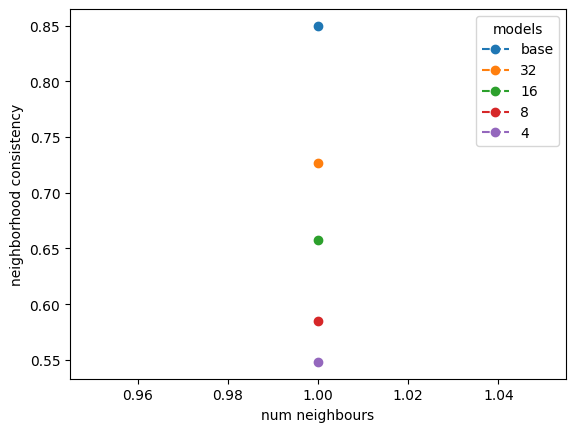

In [7]:
for model_type, curve in consistencies_dict.items():
    plt.plot(k_range, curve, ls='--', marker='o', label=model_type)

plt.xlabel('num neighbours')
plt.ylabel('neighborhood consistency')
plt.legend(title='models')
plt.show()

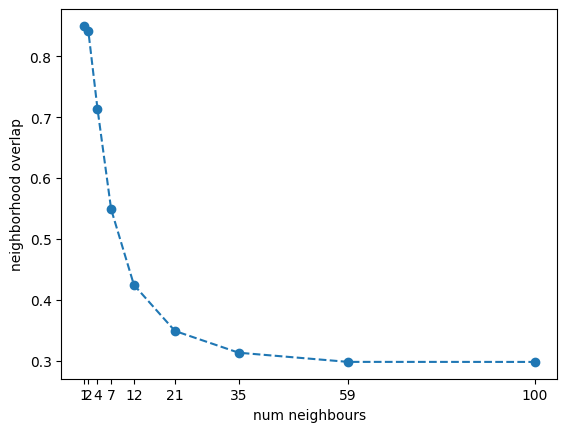

In [9]:
plt.plot(k_range, consistencies, ls='--', marker='o')

plt.xlabel('num neighbours')
plt.ylabel('neighborhood overlap')
plt.xticks(k_range)
plt.show()